<a href="https://colab.research.google.com/github/alt-gabby/qml-assignments/blob/main/4_Quantum_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.6 MB/s eta 0:00:00


moons: train=(160, 4), test=(40, 4)
  norm check (should be ~1.0): 1.000000
circles: train=(160, 4), test=(40, 4)
  norm check (should be ~1.0): 1.000000


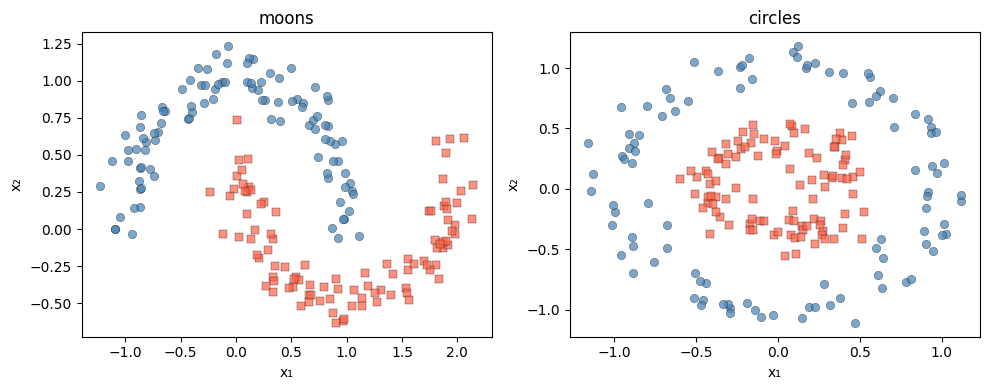

Step 1 done.


In [1]:
# Step 1 — Data generation and preprocessing

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

def make_dataset(name, n_samples=200, noise=0.1, random_state=42):
    if name == "moons":
        X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    elif name == "circles":
        X, y = make_circles(n_samples=n_samples, noise=noise, factor=0.4, random_state=random_state)
    else:
        raise ValueError(f"Unknown dataset: {name}")

    # Map labels {0,1} -> {-1,+1} to match paper's λ1=+1, λ2=-1
    y = 2 * y - 1
    return X, y

def amplitude_encode(X, padding_val=0.0):
    """
    Schuld2020 Eq.(1): normalize and pad each sample to length 2^n.
    Input: X shape (M, N) with N=2 features
    Output: X_enc shape (M, 4) — unit vectors, ready for amplitude encoding
    """
    N = X.shape[1]       # = 2
    target_dim = 4       # 2^2, so we need 2 qubits
    P = target_dim - N   # = 2 padding dimensions

    # Pad with constant padding_val
    pad = np.full((X.shape[0], P), padding_val)
    X_padded = np.hstack([X, pad])

    # L2 normalize (χ in the paper)
    norms = np.linalg.norm(X_padded, axis=1, keepdims=True)
    X_enc = X_padded / norms

    return X_enc

# Generate both datasets
datasets = {}
for name in ["moons", "circles"]:
    X, y = make_dataset(name)
    X_enc = amplitude_encode(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_enc, y, test_size=0.2, random_state=42, stratify=y
    )
    datasets[name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
    }
    print(f"{name}: train={X_train.shape}, test={X_test.shape}")
    print(f"  norm check (should be ~1.0): {np.linalg.norm(X_enc, axis=1).mean():.6f}")

# Visualize raw data (before encoding, for interpretability)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["moons", "circles"]):
    X_raw, y_raw = make_dataset(name)
    for label, color, marker in [(-1, "steelblue", "o"), (1, "tomato", "s")]:
        mask = y_raw == label
        ax.scatter(X_raw[mask, 0], X_raw[mask, 1],
                   c=color, marker=marker, alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.set_title(name)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

plt.tight_layout()
plt.savefig("step1_datasets.png", dpi=120)
plt.show()
print("Step 1 done.")

In [6]:
# Step 2 — QNN circuit definition (Schuld 2020)

import pennylane as qml
from pennylane import numpy as pnp

n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

def layer(params):
    """
    One variational block B_ℓ:
      - Local single-qubit gates G(α,β,γ) on each qubit
        implemented as Rot(α,β,γ) = Rz(γ)Ry(β)Rz(α)
      - Cyclic entangling CNOT (qubit 0 → qubit 1, qubit 1 → qubit 0)
      - Controlled single-qubit gate (target=qubit 0, control=qubit 1)
    params shape: (n_qubits, 3)  — three trainable params per qubit
    """
    for i in range(n_qubits):
        qml.Rot(params[i, 0], params[i, 1], params[i, 2], wires=i)
    # Cyclic entangling code (r=1): CNOT cascade
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i + 1) % n_qubits])

@qml.qnode(dev, interface="autograd")
def circuit(x, weights, bias):
    """
    Full classification circuit:
      1. State prep  : amplitude-encode x (length-4 unit vector → 2-qubit state)
      2. Variational : L blocks of layer()
      3. Final gate  : single Rot on qubit 0 (Gfinal in paper)
      4. Measurement : ⟨Z⟩ on qubit 0  ∈ [-1, +1]
    weights shape : (L, n_qubits, 3)
    bias          : scalar learnable offset (π(x) = ⟨Z⟩ + b)
    """
    # --- state preparation via amplitude encoding ---
    qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=False)

    # --- variational layers ---
    L = weights.shape[0]
    for l in range(L):
        layer(weights[l])

    # --- final single-qubit gate before measurement ---
    # (paper: "having one trainable single-qubit adjustment before measurement
    #  improves quality, often significantly")
    # We fold this into an extra weights entry weights[L-1] already, so no
    # separate parameter needed given our block structure.

    return qml.expval(qml.PauliZ(0))

# Quick sanity check
L = 2
key = pnp.random.seed(0)
w_test = pnp.random.uniform(-np.pi, np.pi, (L, n_qubits, 3), requires_grad=True)
b_test = pnp.array(0.0, requires_grad=True)
x_test = datasets["moons"]["X_train"][0]
out = circuit(x_test, w_test, b_test)
print(f"Circuit output (raw ⟨Z⟩): {float(out):.4f}")
print(qml.draw(circuit)(x_test, w_test, b_test))  # inspect circuit structure

Circuit output (raw ⟨Z⟩): -0.1506
0: ─╭|Ψ⟩──Rot(0.31,1.35,0.65)──╭●─╭X──Rot(-0.39,2.46,2.91)─╭●─╭X─┤  <Z>
1: ─╰|Ψ⟩──Rot(0.28,-0.48,0.92)─╰X─╰●──Rot(-0.73,1.83,0.18)─╰X─╰●─┤     



=== Training QNN on 'moons' ===
  epoch  10/60 | loss=-0.2711 | train_acc=0.650 | test_acc=0.700
  epoch  20/60 | loss=-0.2767 | train_acc=0.656 | test_acc=0.700
  epoch  30/60 | loss=-0.2734 | train_acc=0.662 | test_acc=0.700
  epoch  40/60 | loss=-0.2748 | train_acc=0.656 | test_acc=0.700
  epoch  50/60 | loss=-0.2751 | train_acc=0.656 | test_acc=0.700
  epoch  60/60 | loss=-0.2766 | train_acc=0.656 | test_acc=0.700

=== Training QNN on 'circles' ===
  epoch  10/60 | loss=-0.0358 | train_acc=0.512 | test_acc=0.450
  epoch  20/60 | loss=-0.0403 | train_acc=0.525 | test_acc=0.450
  epoch  30/60 | loss=-0.0386 | train_acc=0.531 | test_acc=0.450
  epoch  40/60 | loss=-0.0394 | train_acc=0.525 | test_acc=0.450
  epoch  50/60 | loss=-0.0398 | train_acc=0.512 | test_acc=0.425
  epoch  60/60 | loss=-0.0417 | train_acc=0.525 | test_acc=0.425


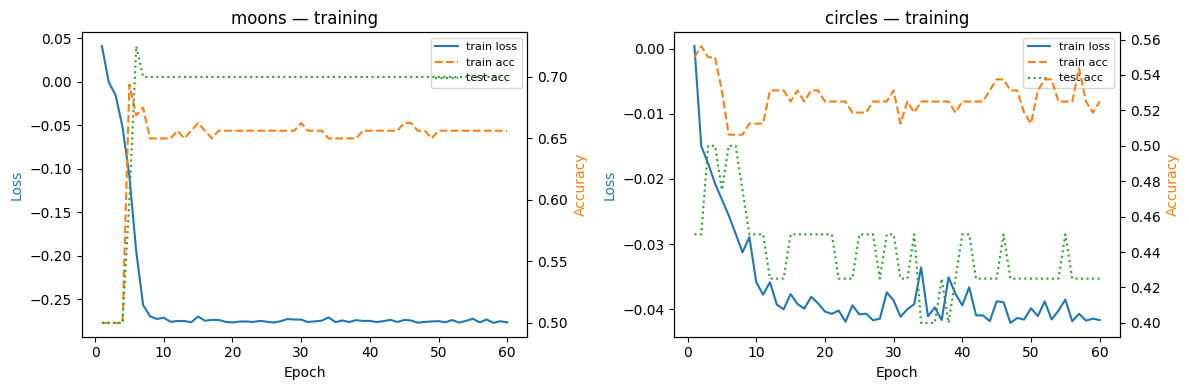

In [7]:
# Step 3 — Loss, prediction, and training

def predict_prob(X, weights, bias):
    """Returns π(x) = ⟨Z⟩ + b for each sample. Shape: (M,)"""
    return pnp.array([float(circuit(x, weights, bias)) + float(bias) for x in X])

def predict_label(X, weights, bias):
    """Thresholds π(x) → {-1, +1}"""
    probs = predict_prob(X, weights, bias)
    return pnp.sign(probs)

def accuracy(X, y, weights, bias):
    preds = predict_label(X, weights, bias)
    return float(pnp.mean(preds == y))

def loss(weights, bias, X_batch, y_batch):
    """
    Utility function from Schuld2020 Eq.(3) — maximise mean likelihood
    ≡ minimise negative mean ⟨ψ|H(θ)|ψ⟩ difference between classes.

    For binary labels y ∈ {-1,+1}:
      L = -1/M · Σ y_i · (⟨Z⟩_i + b)
    This is the mean-margin loss (equivalent to Eq.3 up to a constant).
    """
    outputs = pnp.array(
        [circuit(x, weights, bias) for x in X_batch],
        requires_grad=True
    )
    pi = outputs + bias
    return -pnp.mean(y_batch * pi)

def train_qnn(dataset_name, L=2, n_epochs=60, batch_size=20,
              lr=0.05, random_state=0):
    """
    Full training loop with Adam optimiser.
    Returns weights, bias, and per-epoch history dict.
    """
    pnp.random.seed(random_state)
    weights = pnp.random.uniform(-np.pi, np.pi, (L, n_qubits, 3),
                                  requires_grad=True)
    bias    = pnp.array(0.0, requires_grad=True)

    opt = qml.AdamOptimizer(stepsize=lr)

    X_tr = datasets[dataset_name]["X_train"]
    y_tr = datasets[dataset_name]["y_train"]
    X_te = datasets[dataset_name]["X_test"]
    y_te = datasets[dataset_name]["y_test"]

    M = len(X_tr)
    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(n_epochs):
        # --- mini-batch shuffle ---
        idx = np.random.permutation(M)
        X_sh, y_sh = X_tr[idx], y_tr[idx]

        epoch_loss = 0.0
        n_batches  = 0
        for start in range(0, M, batch_size):
            Xb = X_sh[start:start + batch_size]
            yb = pnp.array(y_sh[start:start + batch_size])

            (weights, bias), batch_l = opt.step_and_cost(
                lambda w, b: loss(w, b, Xb, yb),
                weights, bias
            )
            epoch_loss += float(batch_l)
            n_batches  += 1

        avg_loss  = epoch_loss / n_batches
        tr_acc    = accuracy(X_tr, y_tr, weights, bias)
        te_acc    = accuracy(X_te, y_te, weights, bias)

        history["train_loss"].append(avg_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1:3d}/{n_epochs} | "
                  f"loss={avg_loss:.4f} | "
                  f"train_acc={tr_acc:.3f} | test_acc={te_acc:.3f}")

    return weights, bias, history

# --- train on both datasets ---
results = {}
for name in ["moons", "circles"]:
    print(f"\n=== Training QNN on '{name}' ===")
    w, b, hist = train_qnn(name, L=2, n_epochs=60, batch_size=20, lr=0.05)
    results[name] = {"weights": w, "bias": b, "history": hist}

# --- plot learning curves ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["moons", "circles"]):
    hist = results[name]["history"]
    ep = range(1, len(hist["train_loss"]) + 1)
    ax2 = ax.twinx()
    ax.plot(ep, hist["train_loss"], "C0-",  label="train loss")
    ax2.plot(ep, hist["train_acc"], "C1--", label="train acc")
    ax2.plot(ep, hist["test_acc"],  "C2:",  label="test acc")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss", color="C0")
    ax2.set_ylabel("Accuracy", color="C1")
    ax.set_title(f"{name} — training")
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("step3_training_curves.png", dpi=120)
plt.show()

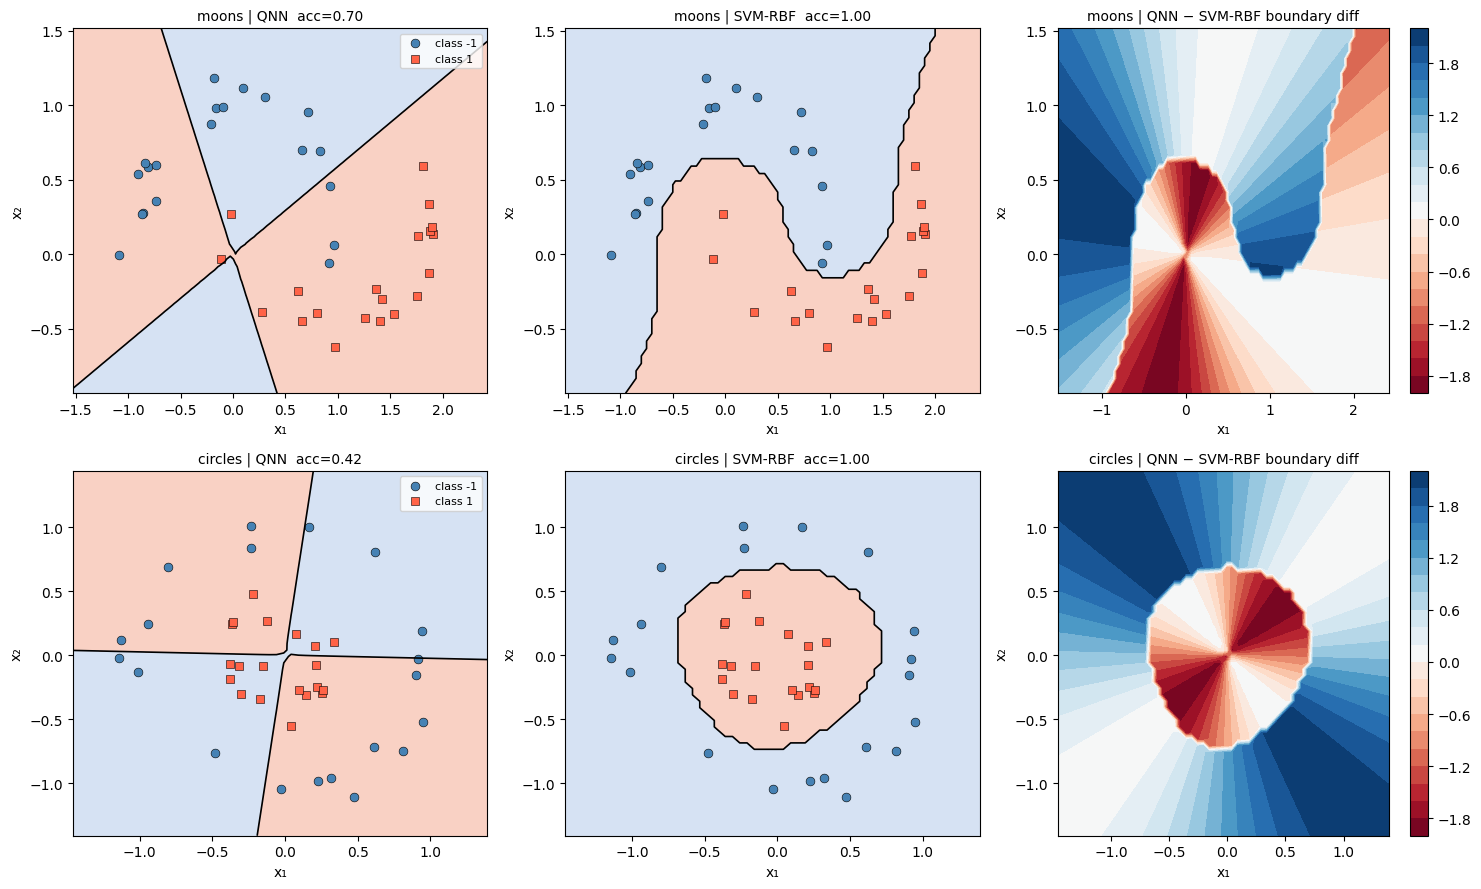


=== Final Accuracy Summary ===
Dataset           QNN    SVM-RBF
moons           0.700      1.000
circles         0.425      1.000


In [8]:
# Step 4 — Classical baseline (RBF-SVM) + decision boundary comparison

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def make_grid(X_raw, h=0.05, margin=0.3):
    x_min, x_max = X_raw[:, 0].min() - margin, X_raw[:, 0].max() + margin
    y_min, y_max = X_raw[:, 1].min() - margin, X_raw[:, 1].max() + margin
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def qnn_predict_grid(xx, yy, weights, bias):
    """Evaluate QNN over a meshgrid (uses amplitude-encoded raw 2D points)."""
    grid_raw = np.c_[xx.ravel(), yy.ravel()]
    grid_enc = amplitude_encode(grid_raw)          # (N_grid, 4)
    Z = predict_prob(grid_enc, weights, bias)
    return Z.reshape(xx.shape)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
col_titles = ["QNN (Schuld2020)", "SVM-RBF (baseline)", "Difference"]

for row, name in enumerate(["moons", "circles"]):
    # --- raw data for plotting ---
    X_raw, y_raw = make_dataset(name)
    X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
    )

    xx, yy = make_grid(X_raw)

    # ---- QNN predictions ----
    w, b = results[name]["weights"], results[name]["bias"]
    Z_qnn = qnn_predict_grid(xx, yy, w, b)

    # ---- SVM-RBF ----
    svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=5, gamma="scale"))
    svm.fit(X_raw_tr, y_raw_tr)          # train on raw (unencoded) features
    Z_svm = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # ---- test accuracies ----
    qnn_acc = accuracy(
        datasets[name]["X_test"],
        datasets[name]["y_test"],
        w, b
    )
    svm_acc = svm.score(X_raw_te, y_raw_te)

    # ---- plot ----
    for col, (Z, title) in enumerate([
        (Z_qnn, f"QNN  acc={qnn_acc:.2f}"),
        (Z_svm.astype(float), f"SVM-RBF  acc={svm_acc:.2f}"),
    ]):
        ax = axes[row, col]
        ax.contourf(xx, yy, Z, levels=[-2, 0, 2],
                    colors=["#aec6e8", "#f4a58a"], alpha=0.5)
        ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=1.2)
        for label, color, marker in [(-1, "steelblue", "o"), (1, "tomato", "s")]:
            m = y_raw_te == label
            ax.scatter(X_raw_te[m, 0], X_raw_te[m, 1],
                       c=color, marker=marker, edgecolors='k',
                       linewidths=0.4, s=40, label=f"class {label}")
        ax.set_title(f"{name} | {title}", fontsize=10)
        ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        if col == 0:
            ax.legend(fontsize=8)

    # ---- difference map ----
    ax = axes[row, 2]
    diff = Z_qnn - Z_svm.astype(float)
    im = ax.contourf(xx, yy, diff, levels=20, cmap="RdBu")
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{name} | QNN − SVM-RBF boundary diff", fontsize=10)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

plt.tight_layout()
plt.savefig("step4_decision_boundaries.png", dpi=120)
plt.show()

# ---- print summary table ----
print("\n=== Final Accuracy Summary ===")
print(f"{'Dataset':<10} {'QNN':>10} {'SVM-RBF':>10}")
for name in ["moons", "circles"]:
    w, b = results[name]["weights"], results[name]["bias"]
    X_raw, y_raw = make_dataset(name)
    _, X_raw_te, _, y_raw_te = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
    )
    svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=5, gamma="scale"))
    X_raw_tr_full, _, y_raw_tr_full, _ = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
    )
    svm.fit(X_raw_tr_full, y_raw_tr_full)
    qnn_acc = accuracy(datasets[name]["X_test"], datasets[name]["y_test"], w, b)
    svm_acc = svm.score(X_raw_te, y_raw_te)
    print(f"{name:<10} {qnn_acc:>10.3f} {svm_acc:>10.3f}")